# Spectral filter example

Here we learn how to evaluate spectral filters using `pyweif`.

**[Run this NB in Google Colab](https://colab.research.google.com/github/matwey/pyweif/blob/master/docs/notebooks/spectral_filter.ipynb)**

## Install and import the required libraries

In [1]:
%pip install pyweif synphot

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from synphot import SpectralElement
from astropy import units as u
import pyweif
import pyweif.sf as sf

In [3]:
bp_v = SpectralElement.from_filter('johnson_v')

grid = bp_v.waveset.to(u.nm)
data = bp_v(grid)
origin = grid[0].value
delta = (grid[1] - grid[0]).value

spectral_response = pyweif.SpectralResponse(data, origin=origin, delta=delta)

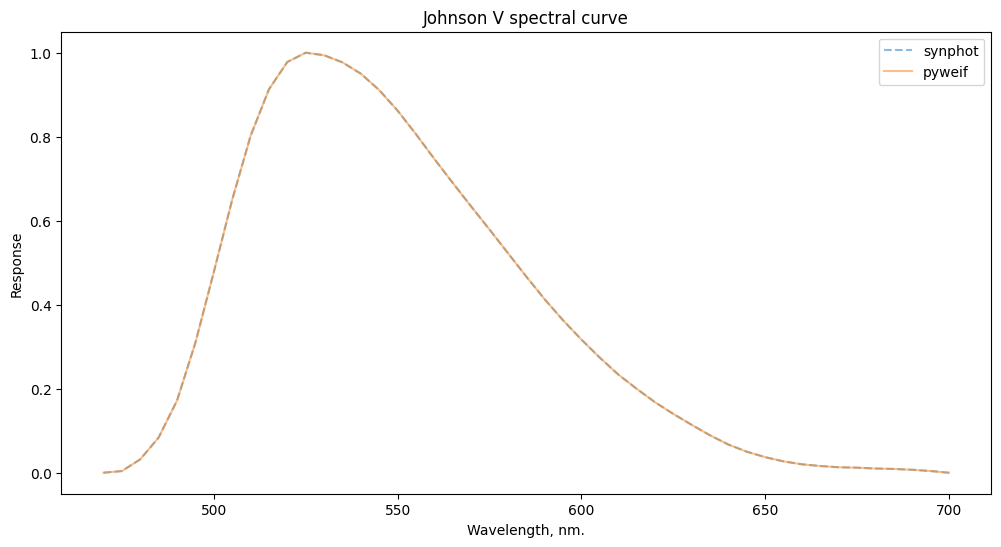

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(grid, data,
         '--', alpha=0.5, label="synphot")
plt.plot(spectral_response.grid(), spectral_response.data(),
         alpha=0.5, label="pyweif")
plt.title("Johnson V spectral curve")
plt.ylabel("Response")
plt.xlabel("Wavelength, nm.")
plt.legend()

pass

In [5]:
spectral_response.normalize()

sf_poly = sf.Poly(spectral_response, 4096)
equiv_lambda = sf_poly.equiv_lambda()
sf_poly.normalize()

sf_gauss = sf.Gauss(fwhm = (bp_v.fwhm() / bp_v.avgwave()).value)

In [6]:
U = np.linspace(0, 5, 1000)

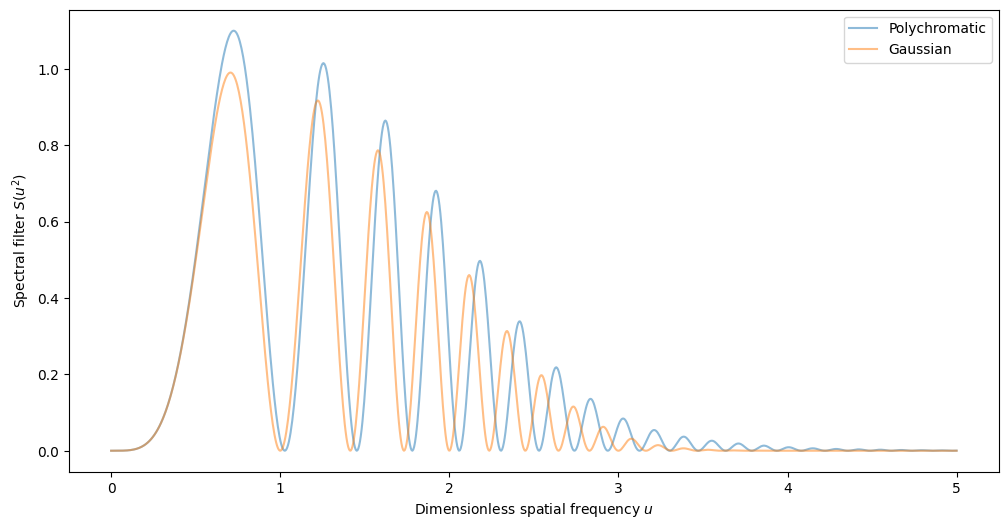

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(U, sf_poly(U**2),
         alpha=0.5, label="Polychromatic")
plt.plot(U, sf_gauss(U**2),
         alpha=0.5, label="Gaussian")
plt.xlabel("Dimensionless spatial frequency $u$")
plt.ylabel("Spectral filter $S(u^2)$")
plt.legend()

pass